    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 0b: Implement a program which, given (a) an (even or odd numbered) imageID or an image file, (b) a user
    selected feature space, and (c) positive integer k, identifies and visualizes the most similar k images, along with
    their scores, under the selected feature space.

In [1]:
IMAGE_INPUT = input(
"""
Provide one of the following:
1. An Image ID in the Caltech101 dataset in range [0, 8676].
2. The name of an image file in /Code/input/ directory (eg: image.jpg).
"""
)

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc].")

K = int(input("Enter K, the number of similar images K to find for the selected feature space."))

Input image:  image.jpg


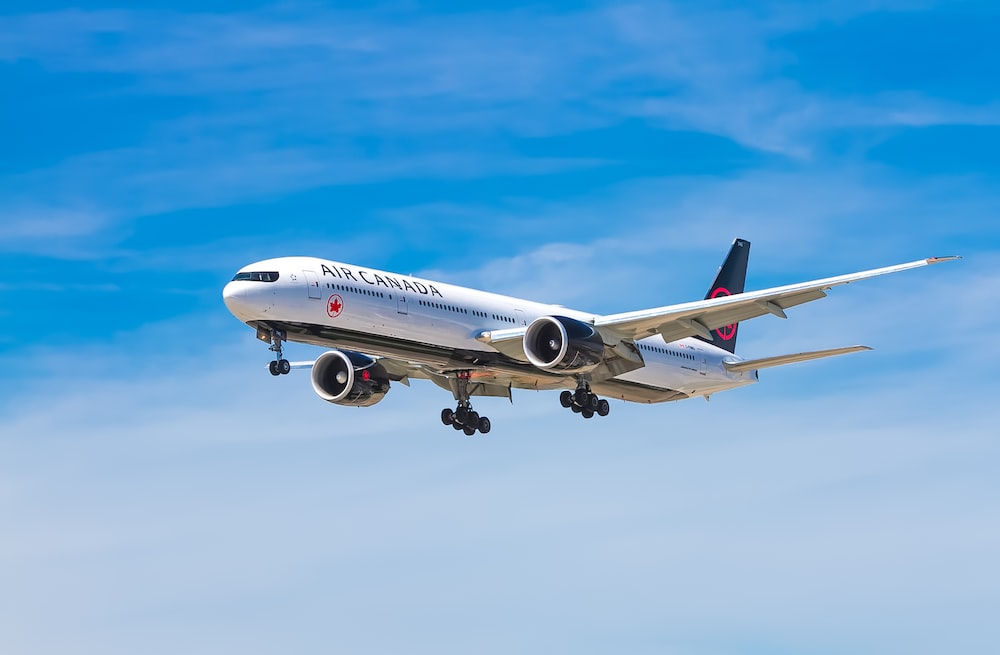

In [2]:
# Find the k most similar images for a given query image for the given feature space.

from utils.query_input_processor import get_query_image

image = get_query_image(IMAGE_INPUT)

print("Input image: ", IMAGE_INPUT)
display(image)

In [3]:
if FEATURE_SPACE == 'color':
    from feature_models.color_moments import ColorMomentsExtractor

    vector = ColorMomentsExtractor(image).get_color_vector()

elif FEATURE_SPACE == 'hog':
    from feature_models.hog import HOGExtractor

    vector = HOGExtractor(image).get_hog_vector()

else:
    # ResNet feature model.
    from feature_models.resnet import ResNetExtractor
    resnet = ResNetExtractor(image)

    if FEATURE_SPACE == 'avgpool':
        vector = resnet.get_avgpool_vector()

    elif FEATURE_SPACE == 'layer3':
        vector = resnet.get_layer3_vector()

    else:
        # fc feature space.
        vector = resnet.get_fc_vector()

Files already downloaded and verified

K = 5  most similar images by  fc  feature space using distance:  cosine
1. 	Image ID:  2254 		Label:  airplanes 		Distance:  0.11802619695663452


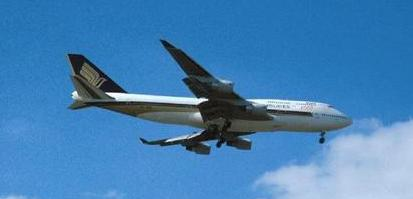

2. 	Image ID:  2308 		Label:  airplanes 		Distance:  0.1238332986831665


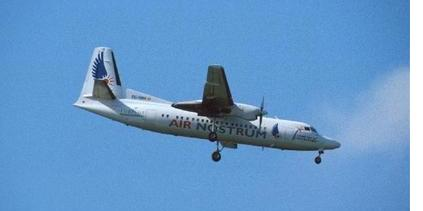

3. 	Image ID:  2226 		Label:  airplanes 		Distance:  0.12936222553253174


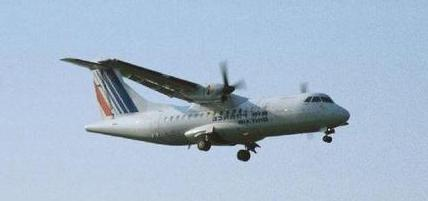

4. 	Image ID:  2670 		Label:  airplanes 		Distance:  0.1307840347290039


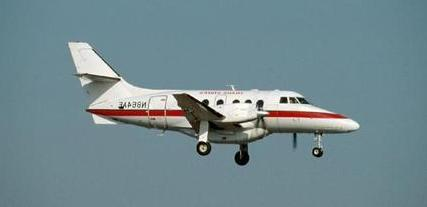

5. 	Image ID:  2484 		Label:  airplanes 		Distance:  0.14001035690307617


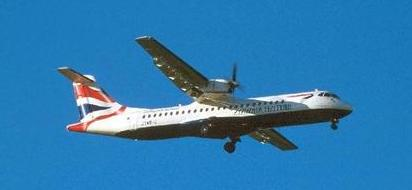

In [4]:
# Load feature space vector database into memory.

from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

from utils.database_utils import retrieve
feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')

from utils.distance_utils import get_distance_fn, top_k_distance_ranker
top_k = top_k_distance_ranker(K, vector, feature_vectors, get_distance_fn(FEATURE_SPACE))

print("\nK =", K, " most similar images by ", FEATURE_SPACE, " feature space using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

for i in range(len(top_k)):

    distance, image_id, label = top_k[i]

    print(str(i + 1) + ".", "\tImage ID: ", image_id, "\t\tLabel: ", label, "\t\tDistance: ", distance)
    display(dataset[image_id][0])